In [1]:
import pandas as pd

df = pd.read_csv("articles.csv")
print(f"articles.csv: {len(df)} строк, колонки: {df.columns.tolist()}")

# Быстрая проверка gold (с фиксом битой строки)
with open("gold.csv", encoding="utf-8") as f:
    lines = f.readlines()

with open("gold.csv", "w", encoding="utf-8") as f:
    for line in lines:
        if line.startswith('2,«Москва, которой нет»,приняла,роль'):
            line = '2,"«Москва, которой нет»",приняла,роль\n'
        f.write(line)

gold = pd.read_csv("gold.csv")
print(f"gold.csv: {len(gold)} строк, колонки: {gold.columns.tolist()}")

articles.csv: 49 строк, колонки: ['Unnamed: 0', 'article', 'theses', 'selected_indices']
gold.csv: 191 строк, колонки: ['text_index', 'subject', 'predicate', 'object']


In [2]:
import re

df = pd.read_csv("articles.csv")
df.columns = df.columns.str.strip()

# Оставляем только текст статьи
df = df.iloc[:, [1]].copy()
df.columns = ["article"]

def clean_text(text):
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"&nbsp;|&#8233;|&amp;", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["article"] = df["article"].apply(clean_text)
print(f"Текстов: {len(df)}")
print(f"Пример: {df['article'].iloc[0][:150]}...")

Текстов: 49
Пример: 63% россиян считают, что забота – это стремление сделать жизнь партнера проще, следует из опроса сервиса «Ясно», с которым ознакомился «Ведомости. Гор...


In [3]:
!nvidia-smi

Tue Sep 29 08:36:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!apt-get update -qq && apt-get install -y -qq zstd
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)
!curl -s http://localhost:11434/api/tags | head -c 200

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../zstd_1.5.5+dfsg2-2build1.1_amd64.deb ...
Unpacking zstd (1.5.5+dfsg2-2build1.1) ...
Setting up zstd (1.5.5+dfsg2-2build1.1) ...
Processing triggers for man-db (2.12.0-4build2) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> C

In [5]:
!pip install -q langextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.3/154.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.2 MB/s eta 0:00:00


In [6]:
!ollama pull qwen3.5:9b

In [7]:
!ollama list

NAME          ID              SIZE      MODIFIED       
qwen3.5:9b    6488c96fa5fa    6.6 GB    11 seconds ago    


In [8]:
import requests, json

r = requests.post("http://localhost:11434/api/generate", json={
    "model": "qwen3.5:9b",
    "prompt": "Ответь одним словом: привет",
    "stream": False,
    "options": {"num_ctx": 4096, "temperature": 0.0, "seed": 42}
}, timeout=600)

print(r.json().get("response", "")[:500])

Привет


In [21]:
import langextract as lx

prompt_v6 = """
Ты извлекаешь триплеты "субъект — предикат — объект" из русских новостных текстов.
Работай строго по правилам. Точность важнее полноты.

ПРАВИЛА:

1. СУБЪЕКТ — существительное или местоимение в ИМЕНИТЕЛЬНОМ падеже.
   ЗАПРЕЩЕНО:
   - Косвенные падежи ("модернизму", "для детей", "Россию").
   - Обстоятельства ("в Москве", "после работы").
   - Числа без существительного ("49%") — разверни до "49% респондентов".
   - Местоимения ("они", "его") — разверни по контексту.
   Если развернуть нельзя — пропусти.

2. ПРЕДИКАТ — глагол в ЛИЧНОЙ форме.
   ЗАПРЕЩЕНО:
   - Причастия: "признан", "зафиксирован", "заявлен", "выставлен", "занесён".
   - Модальные: "можно", "нельзя", "нужно", "важно", "необходимо".
   - Инфинитивы: "сохранить", "использовать".
   РАЗРЕШЕНО:
   - Личные: "считают", "вырос", "сообщил", "состоит", "является".
   - Связка "X — это Y": P="это".
   - Пассив "был выпущен", "были эвакуированы".

3. ОБЪЕКТ — именная группа, до 7 слов.
   ЗАПРЕЩЕНО в объекте:
   - Придаточные с "что", "как", "когда", "чтобы".
   - Целые клаузы: "забота состоит из умения".
   - Числа без существительного: "48 500".
   РАЗРЕШЕНО:
   - Именные группы: "забота", "нужные вещи".
   - Предложные группы с существительным: "о перебоях", "от жары", "на «Грэмми»", "в фильме".
   - Прилагательные и наречия, несущие факт: "комфортным регионом", "гарантией стабильности".
   Если объект длиннее 7 слов — обрежь до ядра + 1–2 зависимых слова.

4. ИСПОЛЬЗУЙ ГЛАГОЛ ИЗ ТЕКСТА.
   Если в тексте "состоит" — пиши "состоит". Не заменяй на "считают".

5. ПРОПУСТИ КЛАУЗУ, если:
   - Нет субъекта в именительном.
   - Нет личного глагола.
   - Объект — придаточная или целая клауза.
   - Это ВВОДНАЯ конструкция: "по данным", "как сообщил", "«Ведомости. Город» писал", "со ссылкой на", "с которым ознакомился".
   - Это РИТОРИЧЕСКИЙ вопрос.

Верни ТОЛЬКО JSON-массив без пояснений:
[{"subject": "...", "predicate": "...", "object": "..."}]
"""

In [22]:
# ============ ПРИМЕР 1: числовой субъект + связка + обрезка ============
example_1 = lx.data.ExampleData(
    text="63% россиян считают, что забота — это стремление сделать жизнь партнёра проще.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="63% россиян считают, что забота — это стремление сделать жизнь партнёра проще",
            attributes={"subject": "63% россиян", "predicate": "считают", "object": "забота"}
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="забота — это стремление сделать жизнь партнёра проще",
            attributes={"subject": "забота", "predicate": "это", "object": "стремление"}
        ),
    ]
)

# ============ ПРИМЕР 2: разворот местоимения + обрезка ============
example_2 = lx.data.ExampleData(
    text="Авторы отвечали на вопросы. Они чаще называют приготовление чая или кофе.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Авторы отвечали на вопросы",
            attributes={"subject": "авторы", "predicate": "отвечали", "object": "вопросы"}
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Они чаще называют приготовление чая или кофе",
            attributes={"subject": "авторы", "predicate": "называют", "object": "приготовление чая"}
        ),
    ]
)

# ============ ПРИМЕР 3: длинный объект → обрезка до ядра ============
example_3 = lx.data.ExampleData(
    text="МЧС России эвакуировало 200 человек из зоны затопления в Курганской области.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="МЧС России эвакуировало 200 человек из зоны затопления в Курганской области",
            attributes={"subject": "МЧС России", "predicate": "эвакуировало", "object": "200 человек"}
        ),
    ]
)

# ============ ПРИМЕР 4: причастие → пропустить ============
example_4 = lx.data.ExampleData(
    text="Копенгаген признан самым комфортным городом мира. Для детей предусмотрен отдельный городок.",
    extractions=[]
)
# "признан" — причастие → пропустить.
# "для детей" — дательный падеж → пропустить.

# ============ ПРИМЕР 5: прилагательное + модальное → пропустить ============
example_5 = lx.data.ExampleData(
    text="Июньская жара стала самой суровой. Монумент нельзя использовать.",
    extractions=[]
)
# "самой суровой" — прилагательное в объекте → пропустить.
# "нельзя" — не глагол → пропустить.

# ============ ПРИМЕР 6: предложные объекты → оставить ============
example_6 = lx.data.ExampleData(
    text="Бонни Тайлер номинировалась на «Грэмми». Она участвовала в конкурсах.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Бонни Тайлер номинировалась на «Грэмми»",
            attributes={"subject": "Бонни Тайлер", "predicate": "номинировалась", "object": "на «Грэмми»"}
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Она участвовала в конкурсах",
            attributes={"subject": "Бонни Тайлер", "predicate": "участвовала", "object": "в конкурсах"}
        ),
    ]
)

examples_v5 = [example_1, example_2, example_3, example_4, example_5, example_6]

In [23]:
import requests, json, time

MODEL_ID = "qwen3.5:9b"   # ← поменяйте на вашу модель

def extract_triplets(text):
    prompt = prompt_v6 + f"""

Верни результат ОДНИМ JSON-ОБЪЕКТОМ НА СТРОКУ, без массива:
{{"subject": "...", "predicate": "...", "object": "..."}}
{{"subject": "...", "predicate": "...", "object": "..."}}

Никаких [ ], запятых между строками, пояснений.

Текст:
{text}"""

    r = requests.post("http://localhost:11434/api/generate", json={
        "model": MODEL_ID,
        "prompt": prompt,
        "think": False,
        "stream": False,
        "options": {
            "num_ctx": 8192,        # ← 8192, не 4096
            "num_predict": 8192,
            "temperature": 0.0,
            "seed": 42
        }
    }, timeout=1800)

    raw = r.json().get("response", "")

    # Парсим построчно, переживаем битые строки
    triplets = []
    for line in raw.strip().split("\n"):
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]"):
            continue
        try:
            obj = json.loads(line)
            if isinstance(obj, dict) and "subject" in obj:
                triplets.append(obj)
        except:
            continue

    # Фолбэк: если построчно не вышло — пробуем как целый JSON-массив
    if not triplets:
        try:
            data = json.loads(raw)
            if isinstance(data, list):
                return data
        except:
            pass
        return []

    return triplets

In [24]:
test_text = df["article"].iloc[0]
print(f"Длина теста: {len(test_text)} символов")
print("Извлекаю...\n")

t0 = time.time()
test_triplets = extract_triplets(test_text)
print(f"Готово за {time.time()-t0:.1f} сек, найдено: {len(test_triplets)}\n")

for i, t in enumerate(test_triplets[:15], 1):
    print(f"[{i}] S={t.get('subject')!r} | P={t.get('predicate')!r} | O={t.get('object')!r}")

Длина теста: 1571 символов
Извлекаю...

Готово за 62.5 сек, найдено: 19

[1] S='63% россиян' | P='считают' | O='что забота – это стремление сделать жизнь партнера проще'
[2] S='забота' | P='состоит' | O='из умения предугадывать потребности'
[3] S='забота' | P='состоит' | O='из эмоциональной связи'
[4] S='проявлять заботу' | P='важно' | O='через поддержку в трудные минуты'
[5] S='проявлять заботу' | P='важно' | O='через внимание к эмоциональному состоянию партнера'
[6] S='проявлять заботу' | P='важно' | O='через помощь в бытовых вопросах'
[7] S='забота' | P='воспринимается' | O='россиянами прежде всего как ежедневная практика'
[8] S='Более половины респондентов' | P='чувствуют себя любимыми' | O='когда партнер покупает нужные вещи без напоминаний'
[9] S='49%' | P='ценят' | O='помощь с задачами, на которые не хватает сил'
[10] S='38%' | P='воспринимают' | O='как проявление заботы собранный на работу обед или заранее подготовленную одежду'
[11] S='сами респонденты' | P='описывают' | O='со

In [25]:
import os

OUTPUT_FILE = "triplets_qwen35_v6.jsonl"
if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)

N_TEXTS = 10   # 10 для сравнения с gold.csv
start_all = time.time()

with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
    for i in range(N_TEXTS):
        text = df["article"].iloc[i]
        print(f"[{i+1}/{N_TEXTS}] text {i} (len={len(text)})...", end=" ")

        t0 = time.time()
        try:
            triplets = extract_triplets(text)
            elapsed = round(time.time() - t0, 1)

            f.write(json.dumps({
                "text_index": i,
                "processing_time": elapsed,
                "num_triplets": len(triplets),
                "triplets": triplets,
            }, ensure_ascii=False) + "\n")
            f.flush()
            print(f"{len(triplets)} triplets, {elapsed}s")
        except Exception as e:
            print(f"ERROR: {e}")
            f.write(json.dumps({
                "text_index": i, "error": str(e), "triplets": []
            }, ensure_ascii=False) + "\n")
            f.flush()

print(f"\nTotal: {(time.time() - start_all)/60:.1f} min")

[1/10] text 0 (len=1571)... 19 triplets, 27.5s
[2/10] text 1 (len=1197)... 10 triplets, 26.9s
[3/10] text 2 (len=17554)... 67 triplets, 134.5s
[4/10] text 3 (len=1645)... 10 triplets, 17.6s
[5/10] text 4 (len=1799)... 13 triplets, 19.6s
[6/10] text 5 (len=4032)... 59 triplets, 97.5s
[7/10] text 6 (len=1453)... 11 triplets, 19.8s
[8/10] text 7 (len=7596)... 89 triplets, 142.2s
[9/10] text 8 (len=1976)... 5 triplets, 10.2s
[10/10] text 9 (len=2217)... 15 triplets, 26.5s

Total: 8.7 min


In [26]:
import json, pandas as pd

records = []
with open("triplets_qwen35_v6.jsonl", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

rows = []
for rec in records:
    for t in rec.get("triplets", []):
        if isinstance(t, dict) and "subject" in t:
            rows.append({
                "text_index": rec["text_index"],
                "subject":    t.get("subject", ""),
                "predicate":  t.get("predicate", ""),
                "object":     t.get("object", ""),
            })

pred_le = pd.DataFrame(rows)
pred_le.to_csv("pred_le_qwen35_v6_raw.csv", index=False, encoding="utf-8")
print(f"Raw: {len(pred_le)} триплетов")
print(f"По текстам:\n{pred_le.groupby('text_index').size()}")

Raw: 298 триплетов
По текстам:
text_index
0    19
1    10
2    67
3    10
4    13
5    59
6    11
7    89
8     5
9    15
dtype: int64


In [14]:
import re

PREPOSITIONS = {"в","во","на","с","со","у","к","ко","о","об","обо","от","до","по",
                "за","из","изо","при","для","без","над","под","про","через","между",
                "перед","возле","около","после","вокруг","среди"}
PRONOUNS = {"он","она","оно","они","его","её","ее","ей","ему","им","ими","их",
            "мы","вы","я","ты","себя","этот","эта","это","эти","тот","та","те",
            "свой","своя","своё","свое","свои","такой","такая","такое","такие"}
MODALS = {"можно","нельзя","нужно","важно","необходимо","должен","должна","должно","должны"}
PARTICIPLE_RE = re.compile(r"(вший|вшая|вшее|вшие|ющий|ющая|ющее|ющие|емый|емая|емое|емые|"
                           r"имый|имая|имое|имые|нный|нная|нное|нные|тый|тая|тое|тые|"
                           r"вшийся|вшаяся|вшееся|вшиеся|ющийся|ющаяся|ющееся|ющиеся|"
                           r"вшись|вши|шись|ясь)$")

def is_bad_row(row):
    s = str(row["subject"]).lower().strip()
    p = str(row["predicate"]).lower().strip()
    o = str(row["object"]).strip()
    if s in PRONOUNS: return True
    if p in MODALS or p in PREPOSITIONS: return True
    if any(PARTICIPLE_RE.search(w) for w in p.split()): return True
    if not s or not p or len(o) < 3: return True
    wo = o.split()
    if wo and wo[-1].lower() in PREPOSITIONS:
        new_o = " ".join(wo[:-1])
        if len(new_o) < 3: return True
        row["object"] = new_o
    return False

def collapse_enumerations(df, min_count=5):
    groups = df.groupby(["text_index","predicate","object"]).size()
    big = groups[groups >= min_count].index
    drop = set()
    for ti, p, o in big:
        idxs = df[(df["text_index"]==ti) & (df["predicate"]==p) & (df["object"]==o)].index.tolist()
        drop.update(idxs[1:])
    return df.drop(index=list(drop))

def drop_near_duplicates(df):
    def key(r):
        return f"{r['text_index']}|{r['subject']}|{r['predicate']}|{' '.join(str(r['object']).split()[:3])}"
    df = df.copy()
    df["_k"] = df.apply(key, axis=1)
    return df.drop_duplicates(subset=["_k"]).drop(columns=["_k"])

def trim_object(obj, max_words=7):
    words = str(obj).split()
    return " ".join(words[:max_words]) if len(words) > max_words else obj

def clean_pipeline(pred_raw):
    df = pred_raw.copy()
    print(f"Raw: {len(df)}")
    df["object"] = df["object"].apply(trim_object)
    mask = ~df.apply(is_bad_row, axis=1)
    df = df[mask]
    print(f"После базовых правил: {len(df)}")
    df = collapse_enumerations(df, min_count=5)
    print(f"После схлопывания: {len(df)}")
    df = drop_near_duplicates(df).reset_index(drop=True)
    print(f"Итого: {len(df)}")
    return df

In [27]:
pred_le_clean = clean_pipeline(pred_le)
pred_le_clean.to_csv("pred_le_qwen35_v6_clean.csv",
                     index=False, encoding="utf-8")

Raw: 298
После базовых правил: 231
После схлопывания: 223
Итого: 222


In [28]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

EMBED_MODEL = SentenceTransformer("intfloat/multilingual-e5-small")

def encode_triplets(df_):
    texts = (df_["subject"].astype(str) + " " +
             df_["predicate"].astype(str) + " " +
             df_["object"].astype(str)).tolist()
    return EMBED_MODEL.encode(texts, normalize_embeddings=True)

def bert_score_prf(pred_df, gold_df, thr=0.75):
    gold_by_text = gold_df.groupby("text_index")
    pred_by_text = pred_df.groupby("text_index")
    rows = []
    for idx in sorted(gold_df["text_index"].unique()):
        g = gold_by_text.get_group(idx)
        if idx not in pred_by_text.groups:
            rows.append({"text_index": idx, "precision": 0.0,
                         "recall": 0.0, "f1": 0.0})
            continue
        p = pred_by_text.get_group(idx)
        if p.empty or g.empty:
            rows.append({"text_index": idx, "precision": 0.0,
                         "recall": 0.0, "f1": 0.0})
            continue
        try:
            g_vecs = encode_triplets(g)
            p_vecs = encode_triplets(p)
        except Exception as e:
            print(f"  [text {idx}] encode error: {e}")
            rows.append({"text_index": idx, "precision": 0.0,
                         "recall": 0.0, "f1": 0.0})
            continue
        sim = cosine_similarity(p_vecs, g_vecs)
        matched = set()
        tp = 0
        for j in range(sim.shape[1]):
            best = int(np.argmax(sim[:, j]))
            if sim[best, j] >= thr and best not in matched:
                tp += 1
                matched.add(best)
        fp = len(p) - len(matched)
        fn = len(g) - tp
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        rows.append({"text_index": idx, "precision": prec,
                     "recall": rec, "f1": f1})
    return pd.DataFrame(rows)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [15]:
def normalize(s):
    if pd.isna(s): return ""
    s = str(s).lower().strip()
    s = re.sub(r"[«»\"'.,;:!?()\[\]—–-]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def triplet_words(df_in):
    return df_in.groupby("text_index").apply(
        lambda g: [set((str(r.subject)+" "+str(r.predicate)+" "+str(r.object)).split())
                   for r in g.itertuples()],
        include_groups=False
    ).to_dict()

def soft_prf(pred_list, ref_list, thr=0.5):
    matched = set(); tp = 0
    for g in ref_list:
        for i, pw in enumerate(pred_list):
            if i in matched or not pw or not g: continue
            j = len(pw & g) / len(pw | g)
            if j >= thr:
                tp += 1; matched.add(i); break
    fp = len(pred_list) - len(matched)
    fn = len(ref_list) - tp
    p = tp/(tp+fp) if tp+fp else 0
    r = tp/(tp+fn) if tp+fn else 0
    f = 2*p*r/(p+r) if p+r else 0
    return p, r, f

def compute_soft_metrics(gold_df, pred_df):
    gold_c = gold_df.copy(); pred_c = pred_df.copy()
    for df_ in [gold_c, pred_c]:
        for col in ["subject", "predicate", "object"]:
            df_[col] = df_[col].apply(normalize)
    gw = triplet_words(gold_c); pw = triplet_words(pred_c)
    rows = []
    for idx in sorted(gold_c["text_index"].unique()):
        p, r, f = soft_prf(pw.get(idx, []), gw.get(idx, []))
        rows.append({"text_index": idx, "precision": p, "recall": r, "f1": f})
    return pd.DataFrame(rows)

In [31]:
def component_words(df_, column):
    """Список множеств слов для одной колонки, сгруппированный по тексту."""
    return df_.groupby("text_index").apply(
        lambda g: [set(str(r).split()) for r in g[column]],
        include_groups=False
    ).to_dict()

def component_f1(pred_df, gold_df, column, thr=0.5):
    pred_w = component_words(pred_df, column)
    gold_w = component_words(gold_df, column)
    rows = []
    for idx in sorted(gold_df["text_index"].unique()):
        pw = pred_w.get(idx, [])
        gw = gold_w.get(idx, [])
        p, r, f = soft_prf(pw, gw, thr=thr)
        rows.append({"text_index": idx, "precision": p,
                     "recall": r, "f1": f})
    return pd.DataFrame(rows)

In [32]:
metrics_raw   = compute_soft_metrics(gold, pred_le)
metrics_clean = compute_soft_metrics(gold, pred_le_clean)

print(f"Raw:     P={metrics_raw['precision'].mean():.3f}  "
      f"R={metrics_raw['recall'].mean():.3f}  "
      f"F1={metrics_raw['f1'].mean():.3f}")
print(f"Cleaned: P={metrics_clean['precision'].mean():.3f}  "
      f"R={metrics_clean['recall'].mean():.3f}  "
      f"F1={metrics_clean['f1'].mean():.3f}")
print(f"Delta F1: {metrics_clean['f1'].mean() - metrics_raw['f1'].mean():+.3f}")

print("\nСчитаю BERTScore...")
bertscore_le = bert_score_prf(pred_le_clean, gold, thr=0.75)
print(f"BERTScore: P={bertscore_le['precision'].mean():.3f}  "
      f"R={bertscore_le['recall'].mean():.3f}  "
      f"F1={bertscore_le['f1'].mean():.3f}")

print("\nF1 по компонентам:")
for comp in ["subject", "predicate", "object"]:
    m = component_f1(pred_le_clean, gold, comp)
    print(f"  {comp:10s}: P={m['precision'].mean():.3f}  "
          f"R={m['recall'].mean():.3f}  F1={m['f1'].mean():.3f}")

Raw:     P=0.272  R=0.308  F1=0.272
Cleaned: P=0.328  R=0.283  F1=0.284
Delta F1: +0.012

Считаю BERTScore...
BERTScore: P=0.647  R=0.624  F1=0.587

F1 по компонентам:
  subject   : P=0.380  R=0.382  F1=0.352
  predicate : P=0.490  R=0.436  F1=0.420
  object    : P=0.200  R=0.218  F1=0.195


In [33]:
import re

def trim_object_hard(o):
    """Жёстко обрезаем объект до ядра: убираем придаточные, длинные хвосты."""
    o = str(o).strip()
    # Убираем начальные союзы
    o = re.sub(r"^(что|как|когда|чтобы)\s+", "", o)
    # Обрезаем по первому союзу/тире/двоеточию
    o = re.split(r"\s+(что|как|когда|чтобы|–|—|:)\s+", o)[0]
    # Максимум 5 слов
    words = o.split()
    return " ".join(words[:5])

pred_v3 = pred_le_clean.copy()
pred_v3["object"] = pred_v3["object"].apply(trim_object_hard)

metrics_v3 = compute_soft_metrics(gold, pred_v3)
print(f"V3: P={metrics_v3['precision'].mean():.3f}  "
      f"R={metrics_v3['recall'].mean():.3f}  "
      f"F1={metrics_v3['f1'].mean():.3f}")

m_obj = component_f1(pred_v3, gold, "object")
print(f"Object F1 после обрезки: {m_obj['f1'].mean():.3f}")

bs_v3 = bert_score_prf(pred_v3, gold, thr=0.75)
print(f"BERTScore F1: {bs_v3['f1'].mean():.3f}")

V3: P=0.338  R=0.306  F1=0.297
Object F1 после обрезки: 0.211
BERTScore F1: 0.591


In [34]:
# есть ли у extraction char_span
for ext in result.extractions[:5]:
    print(f"text='{ext.extraction_text[:60]}'")
    print(f"  char_span={ext.char_interval}")  # если поддерживается
    print(f"  attrs={ext.attributes}")

text='63% россиян считают'
  char_span=CharInterval(start_pos=0, end_pos=19)
  attrs={'subject': '63% россиян', 'predicate': 'считают', 'object': 'что забота — это стремление сделать жизнь партнера проще'}
text='следует из опроса сервиса «Ясно»'
  char_span=CharInterval(start_pos=79, end_pos=111)
  attrs={'subject': 'следует', 'predicate': 'из опроса сервиса «Ясно»', 'object': ''}
text='ознакомился «Ведомости. Город»'
  char_span=CharInterval(start_pos=123, end_pos=153)
  attrs={'subject': 'ознакомился', 'predicate': '«Ведомости. Город»', 'object': ''}
text='Для 58 % забота состоит'
  char_span=CharInterval(start_pos=155, end_pos=178)
  attrs={'subject': 'забота', 'predicate': 'состоит', 'object': 'из умения предугадывать потребности'}
text='для 44% – из эмоциональной связи'
  char_span=CharInterval(start_pos=216, end_pos=248)
  attrs={'subject': 'для 44%', 'predicate': '– из эмоциональной связи', 'object': ''}


In [39]:
# Сверяем char_span с реальным текстом
text = df["article"].iloc[0]

print(f"{'status':<15} {'span':<15} {'match?':<8} text")
print("-" * 80)

exact = fuzzy = 0
for ext in result.extractions[:20]:
    ci = ext.char_interval
    if ci is None:
        status = "NO_SPAN"
    else:
        src = text[ci.start_pos:ci.end_pos]
        if src == ext.extraction_text:
            status = "EXACT"; exact += 1
        elif ext.extraction_text in src or src in ext.extraction_text:
            status = "FUZZY"; fuzzy += 1
        else:
            status = "MISMATCH"
    print(f"{status:<15} ({ci.start_pos},{ci.end_pos})  {ext.extraction_text[:50]!r}")

print(f"\nExact: {exact}, Fuzzy: {fuzzy}")

status          span            match?   text
--------------------------------------------------------------------------------
EXACT           (0,19)  '63% россиян считают'
EXACT           (79,111)  'следует из опроса сервиса «Ясно»'
EXACT           (123,153)  'ознакомился «Ведомости. Город»'
EXACT           (155,178)  'Для 58 % забота состоит'
EXACT           (216,248)  'для 44% – из эмоциональной связи'
EXACT           (259,303)  'проявлять заботу по их мнению наиболее важно'
EXACT           (304,342)  'через поддержку в трудные минуты (62%)'
EXACT           (344,394)  'внимание к эмоциональному состоянию партнера (58%)'
EXACT           (397,428)  'помощь в бытовых вопросах (49%)'
EXACT           (430,453)  'Исследование показывает'
EXACT           (562,619)  'Более половины респондентов (55%) чувствуют себя л'
EXACT           (673,704)  'Еще 49% ценят помощь с задачами'
EXACT           (735,832)  '38% воспринимают как проявление заботы собранный н'
EXACT           (849,931)  'сами р

In [40]:
# HTML-визуализация (открывается в браузере)
lx.io.save_annotated_documents(
    [result],
    output_name="annotated.html",
    output_dir="."
)
print("Откройте annotated.html")

# JSON-экспорт
import json
lx.io.save_annotated_documents(
    [result],
    output_name="annotated.jsonl",
    output_dir="."
)

LangExtract: Saving to annotated.html: 1 docs [00:00, 733.78 docs/s]

✓ Saved 1 documents to annotated.html


Откройте annotated.html


LangExtract: Saving to annotated.jsonl: 1 docs [00:00, 423.03 docs/s]

✓ Saved 1 documents to annotated.jsonl


Длина текста: 17554
Извлечений: 18
Минимальная позиция: 19
Максимальная позиция: 1570
Покрытие текста: 8.9%


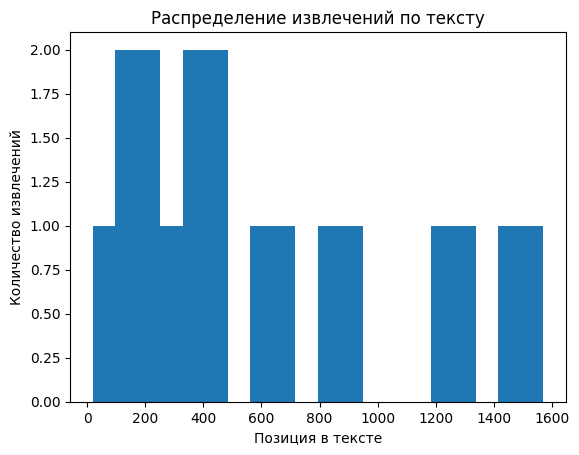

In [41]:
# Считаем сколько раз встречается каждое извлечение
import collections
text = df["article"].iloc[2]

# Проверяем попадает ли что-то в конец текста (последний чанк)
positions = [ext.char_interval.end_pos for ext in result.extractions
             if ext.char_interval]
positions.sort()

print(f"Длина текста: {len(text)}")
print(f"Извлечений: {len(result.extractions)}")
print(f"Минимальная позиция: {min(positions)}")
print(f"Максимальная позиция: {max(positions)}")
print(f"Покрытие текста: {max(positions)/len(text)*100:.1f}%")

# Гистограмма по позициям
import matplotlib.pyplot as plt
plt.hist(positions, bins=20)
plt.xlabel("Позиция в тексте")
plt.ylabel("Количество извлечений")
plt.title("Распределение извлечений по тексту")
plt.show()